Lecture: AI I - Basics 

Previous:
[**Chapter 4.4: Gradiant Boosting**](./04_gradiant_boosting.ipynb)

---

# Chapter 4.3: Conformal Prediction with MAPIE

- [Why Uncertainty?](#why-uncertainty)
- [The Idea of Conformal Prediction](#the-idea-of-conformal-prediction)
- [Split Conformal Classification](#split-conformal-classification)
- [Conformalized Quantile Regression](#conformalized-quantile-regression)
- [What the Guarantee Does Not Say](#what-the-guarantee-does-not-say)

At the end of the last notebook we had a problem: we asked for an 80% prediction interval and got intervals that only contained the truth 70% of the time. This notebook fixes that — with a method that works for *any* model, needs *no* assumptions about the data distribution, and gives a guarantee that already holds for finite samples.

We use [MAPIE](https://mapie.readthedocs.io/en/stable/) (*Model Agnostic Prediction Interval Estimator*), a scikit-learn-contrib library.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightgbm as lgb
from sklearn import datasets
from sklearn.metrics import accuracy_score



## Why Uncertainty?

A classifier tells you "this is class B". A regressor tells you "the value is 173". Both statements are useless on their own if you have to *act* on them:

- A medical model that says "benign" — how sure is it? Would you skip the biopsy?
- A demand forecast of "173 units" — do you stock 173, or 200 to be safe?
- A model deployed on new data — would you like to know when it is out of its depth?

The naive answer is: "use `predict_proba()`". But the probabilities of a neural network or a gradient boosting model are *not* calibrated. A model that outputs 0.9 for a class is not right 90% of the time — usually it is over-confident. Calibration methods (Platt scaling, isotonic regression, see [scikit-learn calibration](https://scikit-learn.org/stable/modules/calibration.html)) help, but they come with their own assumptions and give no guarantee.

Conformal prediction takes a different route. Instead of a probability it returns a **set** (classification) or an **interval** (regression) with a guarantee attached:

$$P\big(y_{\text{new}} \in \hat{C}(x_{\text{new}})\big) \ge 1 - \alpha$$

You choose $\alpha$. If $\alpha = 0.1$, the prediction set contains the true label in at least 90% of cases. The guarantee holds

- for **any** underlying model (linear regression, XGBoost, a neural network, an LLM),
- **without** distributional assumptions,
- for **finite** sample sizes, not just asymptotically.

The price: the model must be treated as a black box, you need to give up some data for calibration, and the guarantee is *marginal* — more on that at the end.

---

## The Idea of Conformal Prediction

The whole method fits on a napkin. It has three steps.

__1. Split your data into three parts.__

| part | used for |
|---|---|
| training set | fitting the model as usual |
| **calibration set** | measuring how wrong the model typically is |
| test set | final evaluation |

__2. Compute a conformity score on the calibration set.__

A *conformity score* $s(x, y)$ measures how badly the model's prediction disagrees with the true value. It has to be large when the model is wrong. Examples:

- regression: $s = |y - \hat{y}|$ — the absolute residual
- classification: $s = 1 - \hat{p}(y \mid x)$ — one minus the predicted probability of the *true* class

Compute this score for every calibration sample. You now have a distribution of "how wrong is my model, empirically".

__3. Take a quantile and build the prediction region.__

Let $\hat{q}$ be the $\lceil (n+1)(1-\alpha) \rceil / n$ quantile of the calibration scores ($n$ = size of the calibration set; the small correction over the plain $1-\alpha$ quantile is what makes the finite-sample guarantee exact). Then, for a new sample, include everything that scores below the threshold:

$$\hat{C}(x_{\text{new}}) = \{ y : s(x_{\text{new}}, y) \le \hat{q} \}$$

For regression this gives the interval $[\hat{y} - \hat{q},\ \hat{y} + \hat{q}]$. For classification it gives the set of all labels whose predicted probability is high enough.

__Why does this work?__ The single assumption is **exchangeability**: the calibration data and the test data come from the same distribution, and the order does not matter. If that holds, the conformity score of a new point is just "another draw" from the same pool as the calibration scores. Asking whether a new score falls below the 90% quantile of $n$ previous scores is then a pure ranking argument — it happens with probability at least 90%, no matter what the model or the distribution looks like.

This variant, where the model is trained once and calibrated on a held-out set, is called **split conformal** (or inductive conformal) prediction. It costs one extra data split and one extra prediction pass — nothing more. There are cross-conformal variants (CV+, jackknife+) which reuse all the data at the cost of training $K$ models; MAPIE implements those too.

> **The rule of thumb for the calibration set:** you need at least $1/\alpha$ samples, and realistically a few hundred to a thousand. For $\alpha = 0.01$ with only 50 calibration points there is no way to estimate a 99% quantile — MAPIE will raise an error.

---

## Split Conformal Classification

We follow the [MAPIE classification quickstart](https://mapie.readthedocs.io/en/stable/generated/classification/1-quickstart/plot_quickstart_classification/), but with a LightGBM model from the previous notebook.

We deliberately use a two-dimensional dataset with **strongly overlapping** classes. On iris, everything would be trivially separable and every prediction set would have size 1 — you would see nothing.

In [2]:
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import (
    classification_coverage_score,
    classification_mean_width_score,
)
from mapie.utils import train_conformalize_test_split

X, y = datasets.make_blobs(n_samples=2000, n_features=2, centers=3,
                           cluster_std=3.5, random_state=42)

(X_train, X_conformalize, X_test,
 y_train, y_conformalize, y_test) = train_conformalize_test_split(
    X, y, train_size=0.5, conformalize_size=0.25, test_size=0.25, random_state=42,
)

print(X_train.shape, X_conformalize.shape, X_test.shape)

(1000, 2) (500, 2) (500, 2)


/tmp/ipykernel_13996/1252706676.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


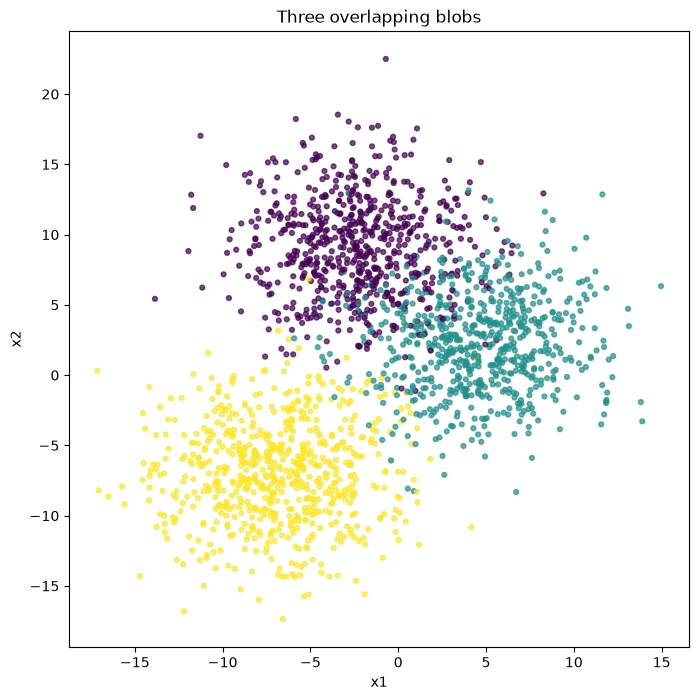

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=12, alpha=0.7)
ax.set(title="Three overlapping blobs", xlabel="x1", ylabel="x2")
fig.show()

First the model, trained completely normally — MAPIE never touches the training:

In [4]:
classifier = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                verbose=-1, random_state=42)
classifier.fit(X_train, y_train)

print(f"accuracy: {accuracy_score(y_test, classifier.predict(X_test)):.3f}")

accuracy: 0.900


Now the conformalization. Three lines: wrap, conformalize, predict.

In [5]:
confidence_level = 0.95      # = 1 - alpha

mapie_classifier = SplitConformalClassifier(
    estimator=classifier,
    confidence_level=confidence_level,
    conformity_score="lac",   # least ambiguous set-valued classifier
    prefit=True,              # our model is already fitted
)
mapie_classifier.conformalize(X_conformalize, y_conformalize)

y_pred, y_pred_set = mapie_classifier.predict_set(X_test)

print(y_pred.shape, y_pred_set.shape)

(500,) (500, 3, 1)


`y_pred` contains the usual point predictions. `y_pred_set` has shape `(n_samples, n_classes, n_confidence_levels)` and is **boolean**: `True` means "this label is in the prediction set".

```python
for i in range(5):
    labels = np.where(y_pred_set[i, :, 0])[0]
    print(f"sample {i}: point prediction = {y_pred[i]}, set = {set(labels)}, true = {y_test[i]}")
```

### Did we get the coverage we asked for?

In [6]:
coverage = classification_coverage_score(y_test, y_pred_set)[0]
mean_width = classification_mean_width_score(y_pred_set)[0]

print(f"target coverage:   {confidence_level:.3f}")
print(f"achieved coverage: {coverage:.3f}")
print(f"average set size:  {mean_width:.2f}")

target coverage:   0.950
achieved coverage: 0.964
average set size:  1.12


That is the whole point: **we asked for 95% and we got 95%** (slightly above, as the guarantee is a lower bound). And we get an interpretable measure of difficulty for free — the size of the set:

/tmp/ipykernel_13996/957734271.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


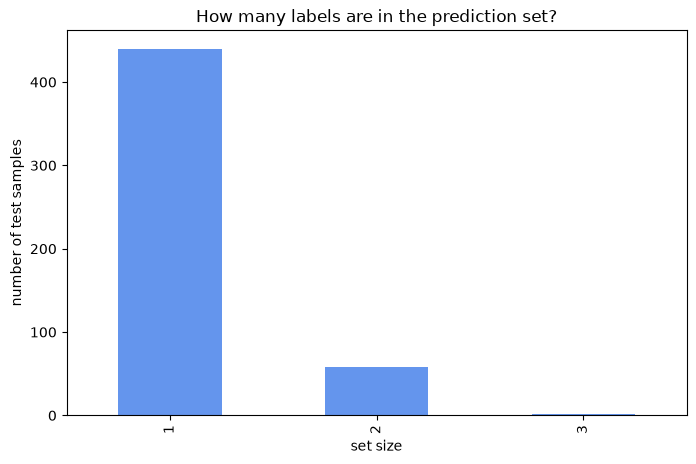

In [7]:
set_sizes = y_pred_set[:, :, 0].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
pd.Series(set_sizes).value_counts().sort_index().plot.bar(ax=ax, color="cornflowerblue")
ax.set(title="How many labels are in the prediction set?",
       xlabel="set size", ylabel="number of test samples")
fig.show()

Most samples get a single label — those are the easy points in the middle of a cluster. Samples in the overlap region get two or three labels: the model *says* it does not know. A point prediction can never express that.

### The effect of the confidence level and of the conformity score

MAPIE offers different conformity scores. The two most common ones:

- `"lac"` (Least Ambiguous set-valued Classifier): score $= 1 - \hat{p}(y \mid x)$. Produces the **smallest possible sets** on average, but can produce **empty sets** when no label is confident enough.
- `"aps"` (Adaptive Prediction Sets): accumulates the sorted probabilities until the true label is reached. Produces larger, but more adaptive sets, and never returns an empty set.

In [8]:
rows = []
for score in ["lac", "aps"]:
    for level in [0.80, 0.95, 0.99]:
        mapie_clf = SplitConformalClassifier(
            estimator=classifier, confidence_level=level,
            conformity_score=score, prefit=True,
        )
        mapie_clf.conformalize(X_conformalize, y_conformalize)
        _, y_set = mapie_clf.predict_set(X_test)

        sizes = y_set[:, :, 0].sum(axis=1)
        rows.append({
            "score": score,
            "target": level,
            "coverage": classification_coverage_score(y_test, y_set)[0],
            "mean size": sizes.mean(),
            "empty sets": int((sizes == 0).sum()),
        })

pd.DataFrame(rows).round(3)

,score,target,coverage,mean size,empty sets
0,lac,0.80,0.830,0.860,70
1,lac,0.95,0.964,1.124,0
2,lac,0.99,0.984,1.262,0
3,aps,0.80,0.938,1.072,0
4,aps,0.95,0.974,1.188,0
5,aps,0.99,0.986,1.316,0


Read this table carefully, it contains three lessons:

1. **Higher confidence costs width.** Going from 80% to 99% grows the average set from 0.86 to 1.26 labels. There is no free lunch: a guarantee you can trust is a guarantee that sometimes has to say "I don't know".
2. **Empty sets are a feature, not a bug.** With `lac` at 80% confidence, 70 test samples get an *empty* set. That means: "not even the most likely label is likely enough for the confidence you demanded". In production you would flag those for a human. If you do not want them, use `aps`.
3. **`aps` overcovers.** At a target of 80% it delivers 94%. The guarantee is a lower bound, and this score is conservative — you pay with wider sets.

### Visualizing the uncertainty

Because the data is two-dimensional we can draw the prediction sets over the whole plane.

/tmp/ipykernel_13996/169103170.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


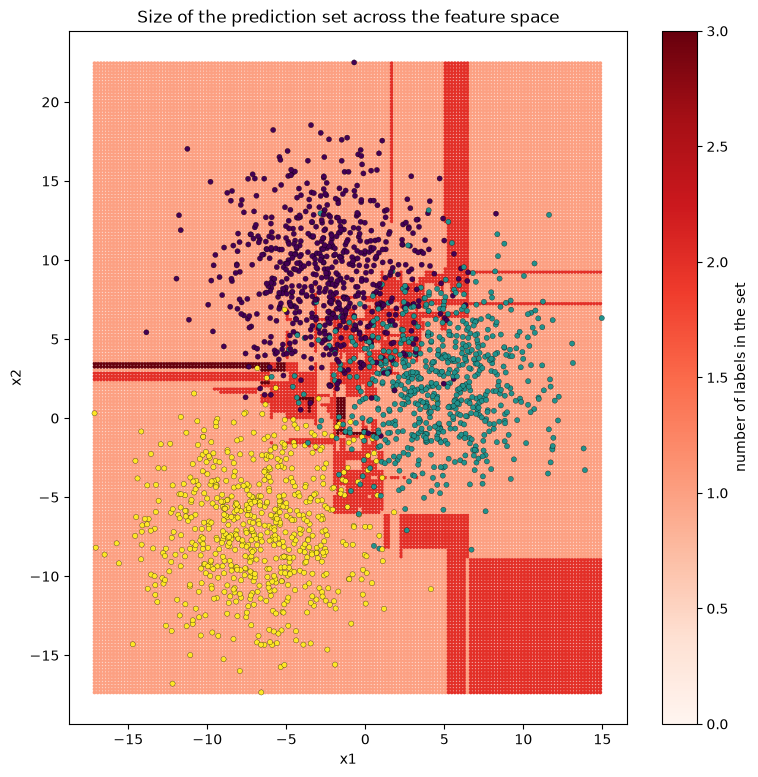

In [9]:
mapie_clf = SplitConformalClassifier(estimator=classifier, confidence_level=0.95,
                                     conformity_score="lac", prefit=True)
mapie_clf.conformalize(X_conformalize, y_conformalize)

# a grid over the feature space
step = 0.2
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))
X_mesh = np.stack([xx.ravel(), yy.ravel()], axis=1)

y_set_mesh = mapie_clf.predict_set(X_mesh)[1][:, :, 0]
mesh_sizes = y_set_mesh.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 9))
contour = ax.scatter(X_mesh[:, 0], X_mesh[:, 1], c=mesh_sizes,
                     cmap="Reds", marker=".", s=12, vmin=0, vmax=3)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=14, edgecolor="k", linewidths=0.2)
ax.set(title="Size of the prediction set across the feature space",
       xlabel="x1", ylabel="x2")
fig.colorbar(contour, ax=ax, label="number of labels in the set")
fig.show()

The white areas are the confident regions inside a cluster; the darker bands are exactly where the clusters overlap — and where any responsible model should abstain.

## Conformalized Quantile Regression

Now back to the problem from the last notebook. We have a quantile regression model whose intervals are adaptive (narrow where the data is easy, wide where it is hard) but whose coverage is wrong. **Conformalized Quantile Regression (CQR)** repairs the coverage and keeps the adaptivity.

The trick is to use the quantile model itself to define the conformity score:

$$s(x, y) = \max\big(\hat{q}_{\text{lo}}(x) - y,\ y - \hat{q}_{\text{hi}}(x)\big)$$

This is "by how much did the interval miss?" — negative when the point is inside, positive when it is outside. Take the appropriate quantile $\hat{q}$ of these scores on the calibration set and widen (or narrow!) the interval by that amount:

$$\hat{C}(x) = \big[\hat{q}_{\text{lo}}(x) - \hat{q},\ \hat{q}_{\text{hi}}(x) + \hat{q}\big]$$

The correction is a single constant, but the interval it corrects is still input-dependent — that is why CQR stays adaptive.

> **MAPIE and XGBoost.** MAPIE has to fit the lower and upper quantile models itself and therefore needs to know which parameters of your estimator control the quantile loss. In MAPIE 1.5 the supported estimators are `QuantileRegressor`, `GradientBoostingRegressor`, `HistGradientBoostingRegressor` and LightGBM's `LGBMRegressor` — `XGBRegressor` is **not** among them. So for CQR we use LightGBM. (If you want to use XGBoost anyway: fit the three quantile models yourself as in Chapter 4.4 and implement the score above by hand — it is about ten lines.)

In [10]:
from mapie.regression import ConformalizedQuantileRegressor, SplitConformalRegressor
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score

X, y = datasets.load_diabetes(return_X_y=True)

(X_train, X_conformalize, X_test,
 y_train, y_conformalize, y_test) = train_conformalize_test_split(
    X, y, train_size=0.6, conformalize_size=0.2, test_size=0.2, random_state=42,
)

confidence_level = 0.8      # alpha = 0.2, as in the last notebook

### The starting point: quantile regression without conformalization


In [11]:
PARAMS = dict(n_estimators=200, learning_rate=0.05, num_leaves=15,
              min_child_samples=20, verbose=-1, random_state=42)

lower_model = lgb.LGBMRegressor(objective="quantile", alpha=0.1, **PARAMS).fit(X_train, y_train)
upper_model = lgb.LGBMRegressor(objective="quantile", alpha=0.9, **PARAMS).fit(X_train, y_train)

# MAPIE expects intervals with shape (n_samples, 2, n_confidence_levels)
raw_intervals = np.stack(
    [lower_model.predict(X_test), upper_model.predict(X_test)], axis=1
)[:, :, np.newaxis]

print(f"coverage: {regression_coverage_score(y_test, raw_intervals)[0]:.3f}")
print(f"width:    {regression_mean_width_score(raw_intervals)[0]:.1f}")

coverage: 0.618
width:    102.3


Same disease as with XGBoost: we asked for 80% and got 62%.

### The cure: CQR

In [12]:
base_model = lgb.LGBMRegressor(objective="quantile", alpha=0.5, **PARAMS)
#                              ^ the quantile loss    ^ MAPIE overwrites this per quantile,
#                                                       but the parameter must exist

cqr = ConformalizedQuantileRegressor(
    estimator=base_model,
    confidence_level=confidence_level,
)
cqr.fit(X_train, y_train)                        # fits the lower, median and upper model
cqr.conformalize(X_conformalize, y_conformalize) # computes the correction

y_pred, y_intervals = cqr.predict_interval(X_test)

print(f"target coverage:   {confidence_level:.3f}")
print(f"achieved coverage: {regression_coverage_score(y_test, y_intervals)[0]:.3f}")
print(f"width:             {regression_mean_width_score(y_intervals)[0]:.1f}")

INFO:root:The predictions are ill-sorted.


target coverage:   0.800
achieved coverage: 0.798
width:             139.4


The interval got about 33% wider — and in exchange the coverage moved from 0.62 to 0.78, essentially on target. (With 89 test samples, a deviation of a few percent around the target is sampling noise, not a broken guarantee.)

### Symmetric and asymmetric correction

By default, MAPIE computes **one** correction from the combined residuals of both bounds and applies it symmetrically. With `symmetric_correction=False` the lower and upper bound get their own correction. This matters when the errors are skewed — see the [MAPIE example on this parameter](https://mapie.readthedocs.io/en/stable/generated/regression/2-advanced-analysis/plot_cqr_symmetry_difference/).

In [13]:
_, intervals_sym = cqr.predict_interval(X_test, symmetric_correction=True)
_, intervals_asym = cqr.predict_interval(X_test, symmetric_correction=False)

for name, intervals in [("symmetric", intervals_sym), ("asymmetric", intervals_asym)]:
    print(f"{name:>10}: coverage = {regression_coverage_score(y_test, intervals)[0]:.3f}, "
          f"width = {regression_mean_width_score(intervals)[0]:.1f}")

INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.


 symmetric: coverage = 0.775, width = 135.6
asymmetric: coverage = 0.798, width = 139.4


The asymmetric variant is slightly wider but hits the target more precisely: it can shift the interval, not just inflate it. As a rule of thumb, use `symmetric_correction=False` when you suspect that the model errs differently at the top and at the bottom (skewed targets such as prices, durations, counts).

### CQR vs. plain split conformal regression

What do we actually gain from the quantile models? Compare against the simplest conformal regressor, which uses the absolute residual of an ordinary (mean) regression:

In [14]:
split_cp = SplitConformalRegressor(
    estimator=lgb.LGBMRegressor(**PARAMS),      # a normal regressor, no quantile loss
    confidence_level=confidence_level,
    prefit=False,
)
split_cp.fit(X_train, y_train)
split_cp.conformalize(X_conformalize, y_conformalize)

_, intervals_split = split_cp.predict_interval(X_test)

widths_split = intervals_split[:, 1, 0] - intervals_split[:, 0, 0]
widths_cqr = intervals_asym[:, 1, 0] - intervals_asym[:, 0, 0]

comparison = pd.DataFrame([
    {"method": "split conformal", "coverage": regression_coverage_score(y_test, intervals_split)[0],
     "mean width": widths_split.mean(), "std of width": widths_split.std()},
    {"method": "CQR", "coverage": regression_coverage_score(y_test, intervals_asym)[0],
     "mean width": widths_cqr.mean(), "std of width": widths_cqr.std()},
]).round(3)

comparison

,method,coverage,mean width,std of width
0,split conformal,0.753,145.779,0.000
1,CQR,0.798,139.433,26.002


Both are valid — both reach roughly the promised coverage. But look at the last column: **split conformal produces intervals of exactly constant width** (every prediction gets the same ± value), while CQR varies the width per sample. On average CQR is even a little narrower here. If you care about knowing *which* predictions are the shaky ones, that difference is the entire value.


/tmp/ipykernel_13996/1092620815.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


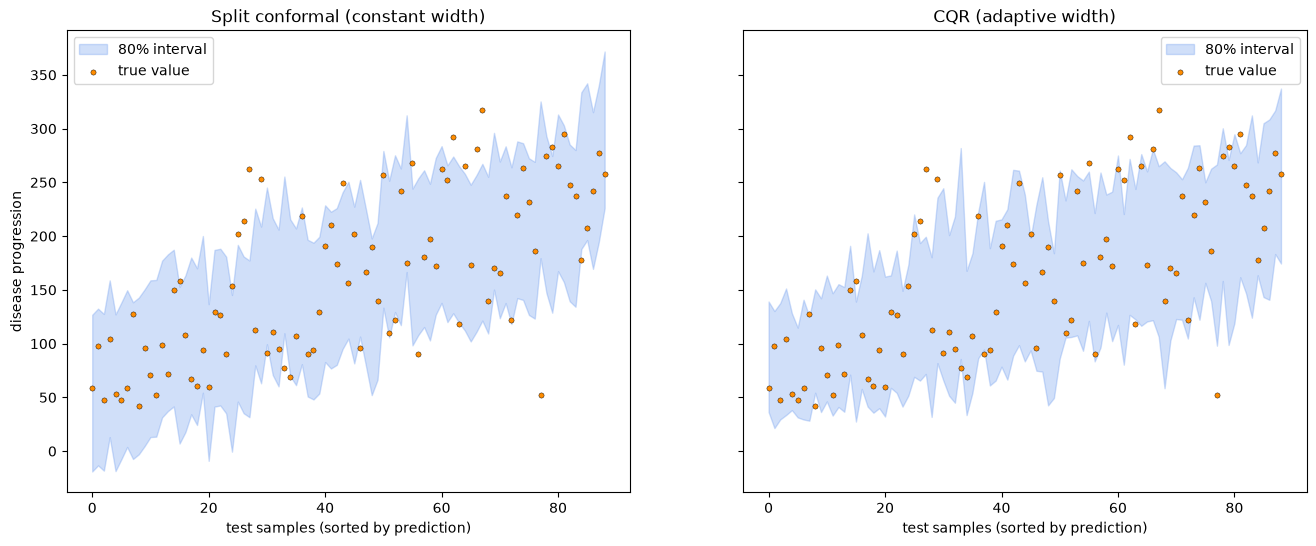

In [15]:
order = np.argsort(y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (name, intervals) in zip(axes, [("Split conformal (constant width)", intervals_split),
                                        ("CQR (adaptive width)", intervals_asym)]):
    ax.fill_between(range(len(order)), intervals[order, 0, 0], intervals[order, 1, 0],
                    alpha=0.3, color="cornflowerblue", label="80% interval")
    ax.scatter(range(len(order)), y_test[order], s=14, c="darkorange",
               edgecolor="black", linewidths=0.3, label="true value")
    ax.set(title=name, xlabel="test samples (sorted by prediction)")
    ax.legend()

axes[0].set_ylabel("disease progression")
fig.show()

## What the Guarantee Does Not Say

Conformal prediction is remarkably useful, but it is easy to over-sell. Three caveats worth stating in an exam answer:

__1. The coverage is marginal, not conditional.__ The promise is "over all new samples, 90% are covered". It is *not* "for every subgroup, 90% are covered". A model can be at 98% for the majority group and 60% for a minority group and still show 90% overall. If subgroup validity matters — and in medicine, credit or hiring it does — check the coverage per group, and look at Mondrian / group-conditional conformal prediction ([MAPIE conditional CP](https://mapie.readthedocs.io/en/stable/generated/conditional_cp/)).

In [16]:
# always worth doing: coverage on the hard and easy half of the data
median_pred = np.median(y_pred)
for name, mask in [("low predictions", y_pred <= median_pred),
                   ("high predictions", y_pred > median_pred)]:
    cov = regression_coverage_score(y_test[mask], intervals_asym[mask])[0]
    print(f"{name:>17}: coverage = {cov:.3f}")

  low predictions: coverage = 0.822
 high predictions: coverage = 0.773


__2. Validity is not the same as usefulness.__ A predictor that always returns "all labels" or the interval $(-\infty, \infty)$ has perfect coverage and zero value. Coverage alone is never the metric — always report the **width** (regression) or the **set size** (classification) alongside it. Improving those means improving the underlying model.

__3. Exchangeability is a real assumption.__ It is much weaker than "i.i.d. Gaussian", but it is not nothing. Distribution shift, time series with trends, data leakage between calibration and training — all break the guarantee, silently.

__What conformal prediction is good for:__ turning any existing model into one that knows when to abstain. It is used for triage in medical imaging (flag the ambiguous scans for a radiologist), for selective prediction in production ML (answer automatically when the set has one element, escalate otherwise), and increasingly for LLM output filtering.

## Summary

| | point prediction | conformal prediction |
|---|---|---|
| output | one label / one number | a set / an interval |
| guarantee | none | $P(y \in \hat{C}(x)) \ge 1 - \alpha$ |
| assumptions | — | exchangeability |
| model requirements | — | none, works as a wrapper |
| extra cost | — | one data split, one prediction pass |
| tells you when it is unsure | no | yes, via the size of the region |

Further reading: the tutorial ["A Gentle Introduction to Conformal Prediction"](https://arxiv.org/abs/2107.07511) by Angelopoulos and Bates is the standard reference and genuinely readable, and the [MAPIE documentation](https://mapie.readthedocs.io/en/stable/content/conformal-prediction/theory/) has an example gallery covering time series, multi-label classification and risk control.

---

Lecture: AI I - Basics 

Exercise: [**Exercise 4.5: Conformal Methods**]()

Next: [**Chapter 5.1: Assesment 1**]()